In [21]:
!pip install pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 9.7 MB/s eta 0:00:00


In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')


Using device: cuda
PyTorch version: 2.10.0+cu128


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ─── SET YOUR BASE PATH ───────────────────────────────────────────────────────
BASE = Path('/content/drive/My Drive/Data/AI MODEL TRAINING DATA/AI MODEL TRAINING DATA')
DATA_DIR      = BASE / 'data'
PCB_TMAP_DIR  = BASE / '_OUT_pcb_tmap'
DIE_TMAP_DIR  = BASE / '_OUT_die_tmap'
FIG_DIR       = BASE / '_OUT_fig6'
TRAINING_XLS  = BASE / 'TRAINING DATA.xlsx'
PROFILES_XLS  = BASE / 'lead_free_reflow_profiles_10.xlsx'
OUTPUT_DIR    = BASE / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

print('✅ Paths set')
print(f'   Data dir   : {DATA_DIR}')
print(f'   PCB maps   : {PCB_TMAP_DIR}')
print(f'   DIE maps   : {DIE_TMAP_DIR}')


Mounted at /content/drive
✅ Paths set
   Data dir   : /content/drive/My Drive/Data/AI MODEL TRAINING DATA/AI MODEL TRAINING DATA/data
   PCB maps   : /content/drive/My Drive/Data/AI MODEL TRAINING DATA/AI MODEL TRAINING DATA/_OUT_pcb_tmap
   DIE maps   : /content/drive/My Drive/Data/AI MODEL TRAINING DATA/AI MODEL TRAINING DATA/_OUT_die_tmap


In [3]:
# ── Auto-detect header row and load TRAINING DATA.xlsx ────────────────────────
raw = pd.read_excel(TRAINING_XLS, header=None)
header_row = raw[raw.eq('peak_temp_C').any(axis=1)].index[0]

train_df = raw.iloc[header_row + 1:].copy()
train_df.columns = raw.iloc[header_row]
train_df = train_df.reset_index(drop=True).dropna(how='all')

# Convert all numeric columns
for col in train_df.columns:
    try:
        train_df[col] = pd.to_numeric(train_df[col])
    except:
        pass

print(f'Training data shape: {train_df.shape}')
print(f'Columns: {train_df.columns.tolist()}')
train_df

Training data shape: (10, 36)
Columns: ['case01', 'T_set_C', 't_total_s', 'T_amb_C', 'ramp_rate_Cps', 'soak_temp_C', 'soak_time_s', 'peak_temp_C', 'tal_s', 'cooling_rate_Cps', 'L_pcb', 'W_pcb', 't_pcb', 'k_pcb_WmK', 'rho_pcb_kgm3', 'cp_pcb_JkgK', 'copper_thickness_um', 'copper_area_fraction', 't_paste_mm', 'k_paste_WmK', 'rho_paste_kgm3', 'cp_paste_JkgK', 'paste_coverage_fraction', 'L_die_mm', 'W_die_mm', 't_die_mm', 'k_die_WmK', 'rho_die_kgm3', 'cp_die_JkgK', 'die_pos_L_mm', 'die_pos_W_mm', 'h_top_Wm2K', 'epsilon', 'R_contact_KW', 'pcb_tmap_file', 'die_tmap_file']


4,case01,T_set_C,t_total_s,T_amb_C,ramp_rate_Cps,soak_temp_C,soak_time_s,peak_temp_C,tal_s,cooling_rate_Cps,...,k_die_WmK,rho_die_kgm3,cp_die_JkgK,die_pos_L_mm,die_pos_W_mm,h_top_Wm2K,epsilon,R_contact_KW,pcb_tmap_file,die_tmap_file
0,1,245,291,25,1.5,165.0,90,245,47,3.0,...,130,2330,700,20,20,10,0.88,0.5,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...
1,2,240,376,25,1.0,162.5,120,240,43,2.5,...,130,2330,700,20,20,10,0.88,0.5,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...
2,3,245,213,25,2.0,167.5,60,245,34,3.5,...,130,2330,700,20,20,10,0.88,0.5,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...
3,4,245,300,25,1.7,170.0,120,245,46,3.0,...,130,2330,700,20,20,10,0.88,0.5,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...
4,5,250,271,25,1.5,165.0,80,250,44,3.2,...,130,2330,700,20,20,10,0.88,0.5,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...
5,6,238,287,25,1.6,162.5,90,238,44,3.0,...,130,2330,700,20,20,10,0.88,0.5,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...
6,7,235,316,25,1.2,155.0,90,235,44,3.0,...,130,2330,700,20,20,10,0.88,0.5,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...
7,8,245,326,25,1.4,165.0,90,245,55,2.0,...,130,2330,700,20,20,10,0.88,0.5,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...
8,9,245,364,25,1.0,165.0,110,245,51,2.8,...,130,2330,700,20,20,10,0.88,0.5,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...
9,10,242,231,25,1.8,162.5,70,242,32,3.4,...,130,2330,700,20,20,10,0.88,0.5,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...,D:\BE Sem - 7\MAJOR_PROJECT-A\AI\FEA T MAP DAT...


In [4]:
# ── Load all 10 PCB + 10 DIE maps ─────────────────────────────────────────────
N_CASES = 10
cases = []

for i in range(1, N_CASES + 1):
    pcb_path = PCB_TMAP_DIR / f'C{i}_PCB_Tmap_50x50.csv'
    die_path = DIE_TMAP_DIR / f'C{i}_DIE_Tmap_50x50.csv'

    pcb_map = pd.read_csv(pcb_path, header=None).values.astype(np.float64)
    die_map = pd.read_csv(die_path, header=None).values.astype(np.float64)

    cases.append({'id': i, 'pcb': pcb_map, 'die': die_map})

print(f'✅ Loaded {len(cases)} cases')
print(f'   PCB map shape: {cases[0]["pcb"].shape}')
print(f'   DIE map shape: {cases[0]["die"].shape}')
print()

# ── Print statistics table ─────────────────────────────────────────────────────
print(f'{"Case":>6}  {"PCB min":>9}  {"PCB max":>9}  {"PCB range":>10}  {"DIE min":>10}  {"DIE max":>10}  {"DIE range":>10}')
print('-' * 75)
for c in cases:
    p, d = c['pcb'], c['die']
    print(f'  C{c["id"]:>2d}   {p.min():9.3f}  {p.max():9.3f}  {p.max()-p.min():10.3f}  {d.min():10.4f}  {d.max():10.4f}  {d.max()-d.min():10.4f}')

✅ Loaded 10 cases
   PCB map shape: (50, 50)
   DIE map shape: (50, 50)

  Case    PCB min    PCB max   PCB range     DIE min     DIE max   DIE range
---------------------------------------------------------------------------
  C 1     231.270    244.218      12.948    231.2970    231.3500      0.0530
  C 2     226.001    238.664      12.663    226.0390    226.0819      0.0429
  C 3     222.958    242.672      19.713    223.0078    223.0713      0.0636
  C 4     231.019    244.185      13.166    231.0581    231.1014      0.0432
  C 5     231.247    248.110      16.863    231.2878    231.3419      0.0541
  C 6     226.707    237.647      10.940    226.7380    226.7809      0.0429
  C 7     225.051    234.704       9.652    225.0783    225.1213      0.0430
  C 8     232.688    244.301      11.613    232.7183    232.7600      0.0417
  C 9     231.762    243.998      12.236    231.7984    231.8413      0.0429
  C10     220.861    239.781      18.920    220.9078    220.9624      0.0546


/tmp/ipython-input-633/92387408.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


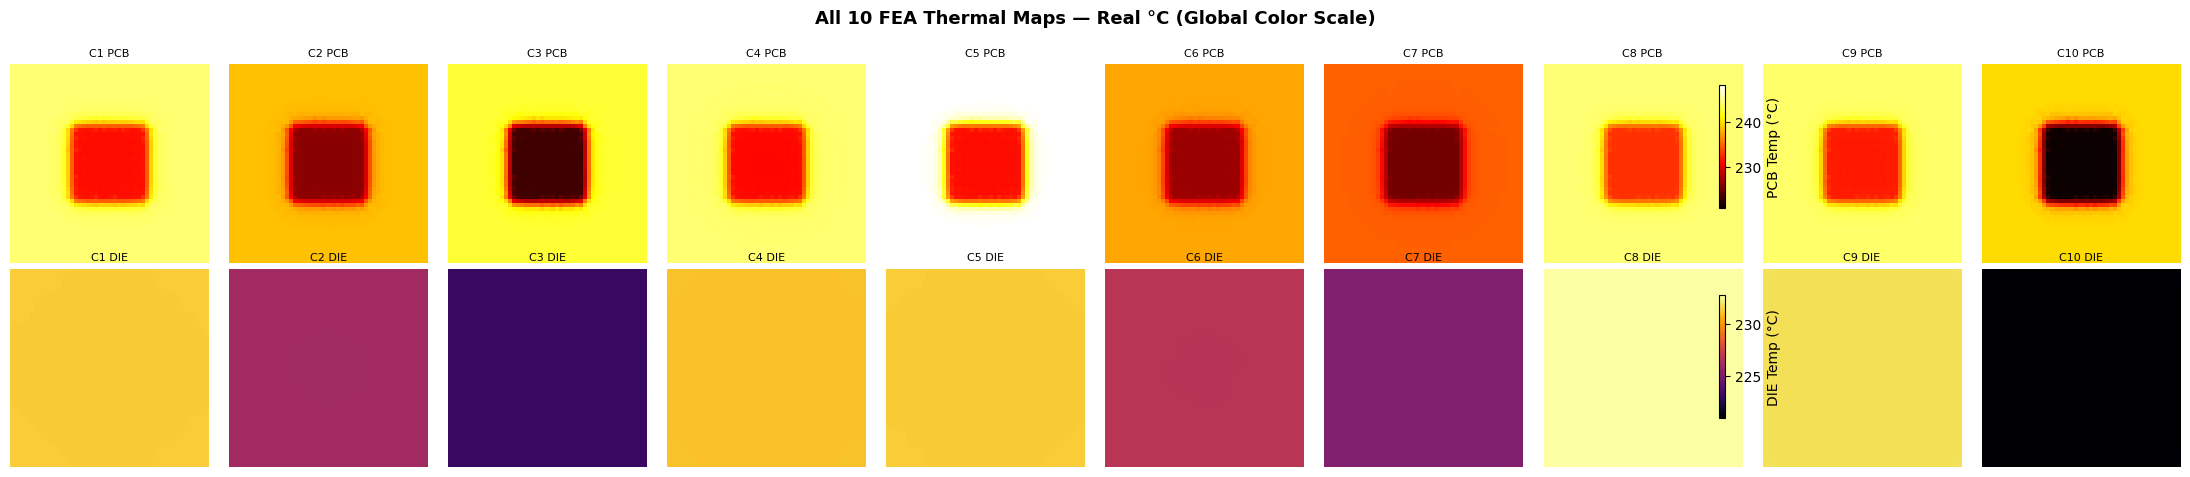

✅ Overview figure saved


In [5]:
# ── Visualize all 10 PCB + DIE maps ───────────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(22, 5))

# Global color scale per component
pcb_vmin = min(c['pcb'].min() for c in cases)
pcb_vmax = max(c['pcb'].max() for c in cases)
die_vmin = min(c['die'].min() for c in cases)
die_vmax = max(c['die'].max() for c in cases)

for i, c in enumerate(cases):
    im0 = axes[0, i].imshow(c['pcb'], cmap='hot', vmin=pcb_vmin, vmax=pcb_vmax, origin='lower')
    axes[0, i].set_title(f'C{c["id"]} PCB', fontsize=8)
    axes[0, i].axis('off')

    im1 = axes[1, i].imshow(c['die'], cmap='inferno', vmin=die_vmin, vmax=die_vmax, origin='lower')
    axes[1, i].set_title(f'C{c["id"]} DIE', fontsize=8)
    axes[1, i].axis('off')

fig.colorbar(im0, ax=axes[0, :], shrink=0.7, label='PCB Temp (°C)')
fig.colorbar(im1, ax=axes[1, :], shrink=0.7, label='DIE Temp (°C)')
fig.suptitle('All 10 FEA Thermal Maps — Real °C (Global Color Scale)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig0_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Overview figure saved')


In [6]:
# ── 12 physics-meaningful input features ──────────────────────────────────────
FEATURE_COLS = [
    'peak_temp_C',           # primary reflow driver
    'tal_s',                 # time above liquidus (SAC305: 217°C)
    'soak_temp_C',           # soak zone temperature
    'soak_time_s',           # soak duration
    'ramp_rate_Cps',         # heating ramp rate
    'cooling_rate_Cps',      # cooling rate
    't_total_s',             # total profile duration
    'T_amb_C',               # ambient temperature
    'copper_area_fraction',  # PCB copper coverage (affects conductivity)
    'paste_coverage_fraction', # solder paste coverage
    'k_die_WmK',             # die thermal conductivity
    'k_pcb_WmK',             # PCB thermal conductivity
]

X_raw = train_df[FEATURE_COLS].values.astype(np.float32)
print(f'Feature matrix shape: {X_raw.shape}  ({len(FEATURE_COLS)} features × {len(cases)} cases)')
print()
print('Feature ranges:')
for i, col in enumerate(FEATURE_COLS):
    print(f'  {col:<30s}: {X_raw[:, i].min():.3f} → {X_raw[:, i].max():.3f}')

Feature matrix shape: (10, 12)  (12 features × 10 cases)

Feature ranges:
  peak_temp_C                   : 235.000 → 250.000
  tal_s                         : 32.000 → 55.000
  soak_temp_C                   : 155.000 → 170.000
  soak_time_s                   : 60.000 → 120.000
  ramp_rate_Cps                 : 1.000 → 2.000
  cooling_rate_Cps              : 2.000 → 3.500
  t_total_s                     : 213.000 → 376.000
  T_amb_C                       : 25.000 → 25.000
  copper_area_fraction          : 0.150 → 0.400
  paste_coverage_fraction       : 0.010 → 0.030
  k_die_WmK                     : 130.000 → 130.000
  k_pcb_WmK                     : 0.300 → 0.300


In [35]:
# ── Global normalization of input features ─────────────────────────────────────
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X_raw).astype(np.float32)
print('✅ Input features normalized (StandardScaler)')

# ── PCB — global normalization (13°C range, works fine globally) ───────────────
all_pcb  = np.stack([c['pcb'] for c in cases])
PCB_MEAN = all_pcb.mean()
PCB_STD  = all_pcb.std()

# ── DIE — per-case normalization (amplifies tiny 0.05°C spatial signal) ────────
DIE_MEANS = [c['die'].mean() for c in cases]
DIE_STDS  = [c['die'].std() + 1e-8 for c in cases]

print(f'\nPCB global stats : mean={PCB_MEAN:.3f}°C  std={PCB_STD:.3f}°C')
print(f'DIE per-case std range: {min(DIE_STDS):.6f} → {max(DIE_STDS):.6f}°C')
print('✅ DIE using per-case normalization to preserve 0.05°C spatial signal')

NORM_PARAMS = {
    'pcb_mean':  PCB_MEAN,
    'pcb_std':   PCB_STD,
    'die_means': DIE_MEANS,
    'die_stds':  DIE_STDS,
}

def normalize_pcb(x):          return (x - PCB_MEAN) / PCB_STD
def denormalize_pcb(x):        return x * PCB_STD + PCB_MEAN
def normalize_die(x, idx):     return (x - DIE_MEANS[idx]) / DIE_STDS[idx]
def denormalize_die(x, idx):   return x * DIE_STDS[idx] + DIE_MEANS[idx]

✅ Input features normalized (StandardScaler)

PCB global stats : mean=239.502°C  std=6.096°C
DIE per-case std range: 0.008339 → 0.013035°C
✅ DIE using per-case normalization to preserve 0.05°C spatial signal


In [36]:
import torch.nn.functional as F

# ── Dataset ────────────────────────────────────────────────────────────────────
class ThermalDataset(Dataset):
    def __init__(self, case_list, features, case_indices):
        self.cases        = case_list
        self.features     = features
        self.case_indices = case_indices  # original indices for per-case DIE norm

    def __len__(self):
        return len(self.cases)

    def __getitem__(self, idx):
        c    = self.cases[idx]
        orig = self.case_indices[idx]

        pcb = torch.tensor(normalize_pcb(c['pcb']),       dtype=torch.float32).unsqueeze(0)
        die = torch.tensor(normalize_die(c['die'], orig), dtype=torch.float32).unsqueeze(0)
        x   = torch.tensor(self.features[idx],            dtype=torch.float32)

        return x, pcb, die, orig  # ← orig needed for denormalization


# ── Model ──────────────────────────────────────────────────────────────────────
class ThermalDigitalTwin(nn.Module):
    def __init__(self, in_features=12, dropout=0.1):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.GELU(),
        )
        self.project = nn.Sequential(
            nn.Linear(512, 64 * 8 * 8),
            nn.GELU(),
        )

        self.pcb_decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.InstanceNorm2d(32), nn.GELU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.InstanceNorm2d(16), nn.GELU(),
            nn.ConvTranspose2d(16,  1, 4, stride=2, padding=1),
        )

        self.die_decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.InstanceNorm2d(32), nn.GELU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.InstanceNorm2d(16), nn.GELU(),
            nn.ConvTranspose2d(16,  1, 4, stride=2, padding=1),
        )

    def forward(self, x):
        z   = self.encoder(x)
        z   = self.project(z)
        z   = z.view(-1, 64, 8, 8)
        pcb = F.interpolate(self.pcb_decoder(z), size=(50,50), mode='bilinear', align_corners=False)
        die = F.interpolate(self.die_decoder(z), size=(50,50), mode='bilinear', align_corners=False)
        return pcb, die


# Quick test
m = ThermalDigitalTwin(in_features=12).to(device)
dummy = torch.zeros(2, 12).to(device)
p, d = m(dummy)
print(f'✅ Model OK  |  PCB: {p.shape}  |  DIE: {d.shape}')
print(f'   Params: {sum(p.numel() for p in m.parameters()):,}')

✅ Model OK  |  PCB: torch.Size([2, 1, 50, 50])  |  DIE: torch.Size([2, 1, 50, 50])
   Params: 2,320,226


In [37]:
def gradient_loss(pred):
    """
    Penalize sharp spatial gradients (encourages physically smooth fields).
    pred: (B, 1, H, W)
    """
    dy = torch.abs(pred[:, :, 1:, :] - pred[:, :, :-1, :])
    dx = torch.abs(pred[:, :, :, 1:] - pred[:, :, :, :-1])
    return dy.mean() + dx.mean()


def uniformity_loss(pred):
    """
    Penalize high spatial std (encourages uniform heating — key for DIE).
    pred: (B, 1, H, W)
    """
    return pred.std(dim=[2, 3]).mean()


def physics_loss(pcb_pred, die_pred, pcb_true, die_true,
                 lambda_grad=0.05, lambda_uni=0.1):
    """
    Combined physics-informed loss.
    """
    # Reconstruction losses
    mse_pcb = F.mse_loss(pcb_pred, pcb_true)
    mse_die = F.mse_loss(die_pred, die_true)

    # Physics regularization
    grad_pcb = gradient_loss(pcb_pred)
    uni_die  = uniformity_loss(die_pred)

    total = mse_pcb + mse_die + lambda_grad * grad_pcb + lambda_uni * uni_die

    return total, {
        'mse_pcb': mse_pcb.item(),
        'mse_die': mse_die.item(),
        'grad_pcb': grad_pcb.item(),
        'uni_die': uni_die.item(),
    }


print('✅ Physics-informed loss defined')
print('   Components: MSE(PCB) + MSE(DIE) + λ·Gradient(PCB) + λ·Uniformity(DIE)')

✅ Physics-informed loss defined
   Components: MSE(PCB) + MSE(DIE) + λ·Gradient(PCB) + λ·Uniformity(DIE)


In [40]:
# ── Training config ────────────────────────────────────────────────────────────
EPOCHS_PER_FOLD = 150
LR              = 5e-4
BATCH_SIZE      = 4
LAMBDA_GRAD     = 0.05
LAMBDA_UNI      = 0.10


def train_fold(train_cases, train_features, val_cases, val_features,
               train_idx, val_idx,
               fold_id, epochs=EPOCHS_PER_FOLD, verbose=True):

    train_ds = ThermalDataset(train_cases, train_features, list(train_idx))
    val_ds   = ThermalDataset(val_cases,   val_features,   list(val_idx))
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_dl   = DataLoader(val_ds,   batch_size=1,          shuffle=False)

    model     = ThermalDigitalTwin(in_features=len(FEATURE_COLS)).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    train_hist = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for x, pcb, die, _ in train_dl:
            x, pcb, die = x.to(device), pcb.to(device), die.to(device)
            pcb_pred, die_pred = model(x)
            loss, _ = physics_loss(pcb_pred, die_pred, pcb, die, LAMBDA_GRAD, LAMBDA_UNI)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        train_hist.append(epoch_loss / len(train_dl))

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_losses  = []
    val_outputs = []

    with torch.no_grad():
        for x, pcb, die, orig_idx in val_dl:
            x, pcb, die = x.to(device), pcb.to(device), die.to(device)
            pcb_pred, die_pred = model(x)
            loss, comps = physics_loss(pcb_pred, die_pred, pcb, die, LAMBDA_GRAD, LAMBDA_UNI)
            val_losses.append(loss.item())

            idx = orig_idx[0].item()
            val_outputs.append({
                'pcb_pred': denormalize_pcb(pcb_pred.cpu().numpy()[0, 0]),
                'die_pred': denormalize_die(die_pred.cpu().numpy()[0, 0], idx),
                'pcb_true': denormalize_pcb(pcb.cpu().numpy()[0, 0]),
                'die_true': denormalize_die(die.cpu().numpy()[0, 0], idx),
                'comps':    comps,
            })

    val_loss = np.mean(val_losses)
    if verbose:
        print(f'  Fold {fold_id:2d} | Val Loss: {val_loss:.4f} | '
              f'mse_pcb={comps["mse_pcb"]:.4f} | mse_die={comps["mse_die"]:.4f}')

    return model, val_loss, train_hist, val_outputs

print('✅ Training function defined')

✅ Training function defined


In [41]:
print('🔁 Running Leave-One-Out Cross-Validation (10 folds)...\n')

loo     = LeaveOneOut()
indices = np.arange(len(cases))

fold_results    = []
all_train_hists = []

for fold, (train_idx, val_idx) in enumerate(loo.split(indices)):
    train_cases    = [cases[i] for i in train_idx]
    val_cases      = [cases[i] for i in val_idx]
    train_features = X_scaled[train_idx]
    val_features   = X_scaled[val_idx]

    model_fold, val_loss, train_hist, val_outputs = train_fold(
        train_cases, train_features,
        val_cases,   val_features,
        train_idx = train_idx,
        val_idx   = val_idx,
        fold_id   = val_idx[0] + 1
    )

    fold_results.append({
        'fold':     val_idx[0] + 1,
        'val_loss': val_loss,
        'outputs':  val_outputs,
        'model':    model_fold,
    })
    all_train_hists.append(train_hist)

print()
val_losses = [r['val_loss'] for r in fold_results]
print(f'✅ LOOCV complete')
print(f'   Mean val loss : {np.mean(val_losses):.4f}')
print(f'   Std  val loss : {np.std(val_losses):.4f}')
print(f'   Min  val loss : {np.min(val_losses):.4f}  (Fold {np.argmin(val_losses)+1})')
print(f'   Max  val loss : {np.max(val_losses):.4f}  (Fold {np.argmax(val_losses)+1})')

🔁 Running Leave-One-Out Cross-Validation (10 folds)...

  Fold  1 | Val Loss: 0.5258 | mse_pcb=0.2724 | mse_die=0.1443
  Fold  2 | Val Loss: 0.7826 | mse_pcb=0.4735 | mse_die=0.2019
  Fold  3 | Val Loss: 0.1897 | mse_pcb=0.0337 | mse_die=0.0465
  Fold  4 | Val Loss: 0.2346 | mse_pcb=0.0196 | mse_die=0.1069
  Fold  5 | Val Loss: 0.8127 | mse_pcb=0.6262 | mse_die=0.0801
  Fold  6 | Val Loss: 0.2733 | mse_pcb=0.0699 | mse_die=0.0954
  Fold  7 | Val Loss: 0.6862 | mse_pcb=0.4484 | mse_die=0.1339
  Fold  8 | Val Loss: 0.2470 | mse_pcb=0.0293 | mse_die=0.1110
  Fold  9 | Val Loss: 0.4407 | mse_pcb=0.2030 | mse_die=0.1286
  Fold 10 | Val Loss: 0.2150 | mse_pcb=0.0356 | mse_die=0.0703

✅ LOOCV complete
   Mean val loss : 0.4408
   Std  val loss : 0.2334
   Min  val loss : 0.1897  (Fold 3)
   Max  val loss : 0.8127  (Fold 5)


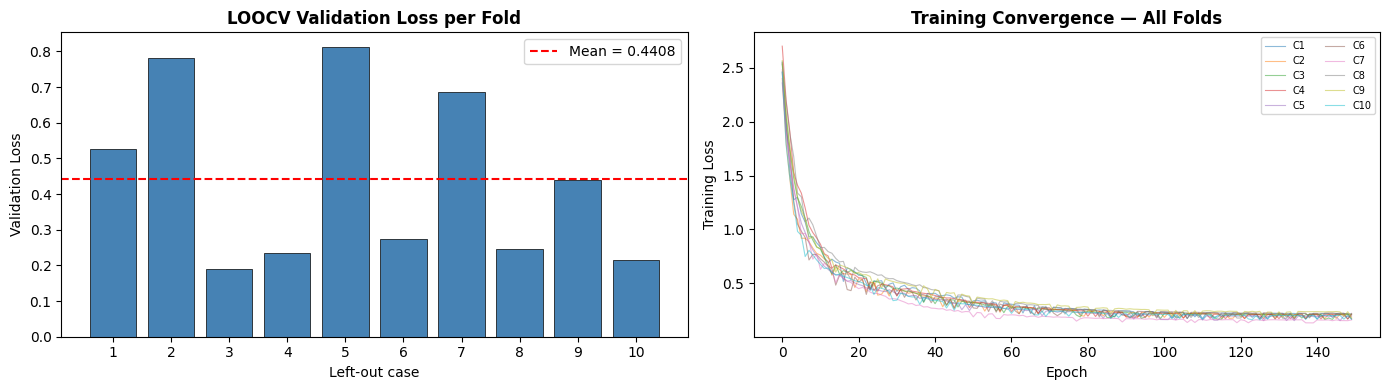

In [42]:
# ── LOOCV Loss per fold ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss per fold bar chart
folds = [r['fold'] for r in fold_results]
losses = [r['val_loss'] for r in fold_results]
axes[0].bar(folds, losses, color='steelblue', edgecolor='k', linewidth=0.5)
axes[0].axhline(np.mean(losses), color='red', ls='--', label=f'Mean = {np.mean(losses):.4f}')
axes[0].set_xlabel('Left-out case'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('LOOCV Validation Loss per Fold', fontweight='bold')
axes[0].legend(); axes[0].set_xticks(folds)

# Training convergence (all folds)
for i, hist in enumerate(all_train_hists):
    axes[1].plot(hist, alpha=0.5, linewidth=0.8, label=f'C{i+1}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Training Loss')
axes[1].set_title('Training Convergence — All Folds', fontweight='bold')
axes[1].legend(ncol=2, fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_loocv_results.png', dpi=200, bbox_inches='tight')
plt.show()

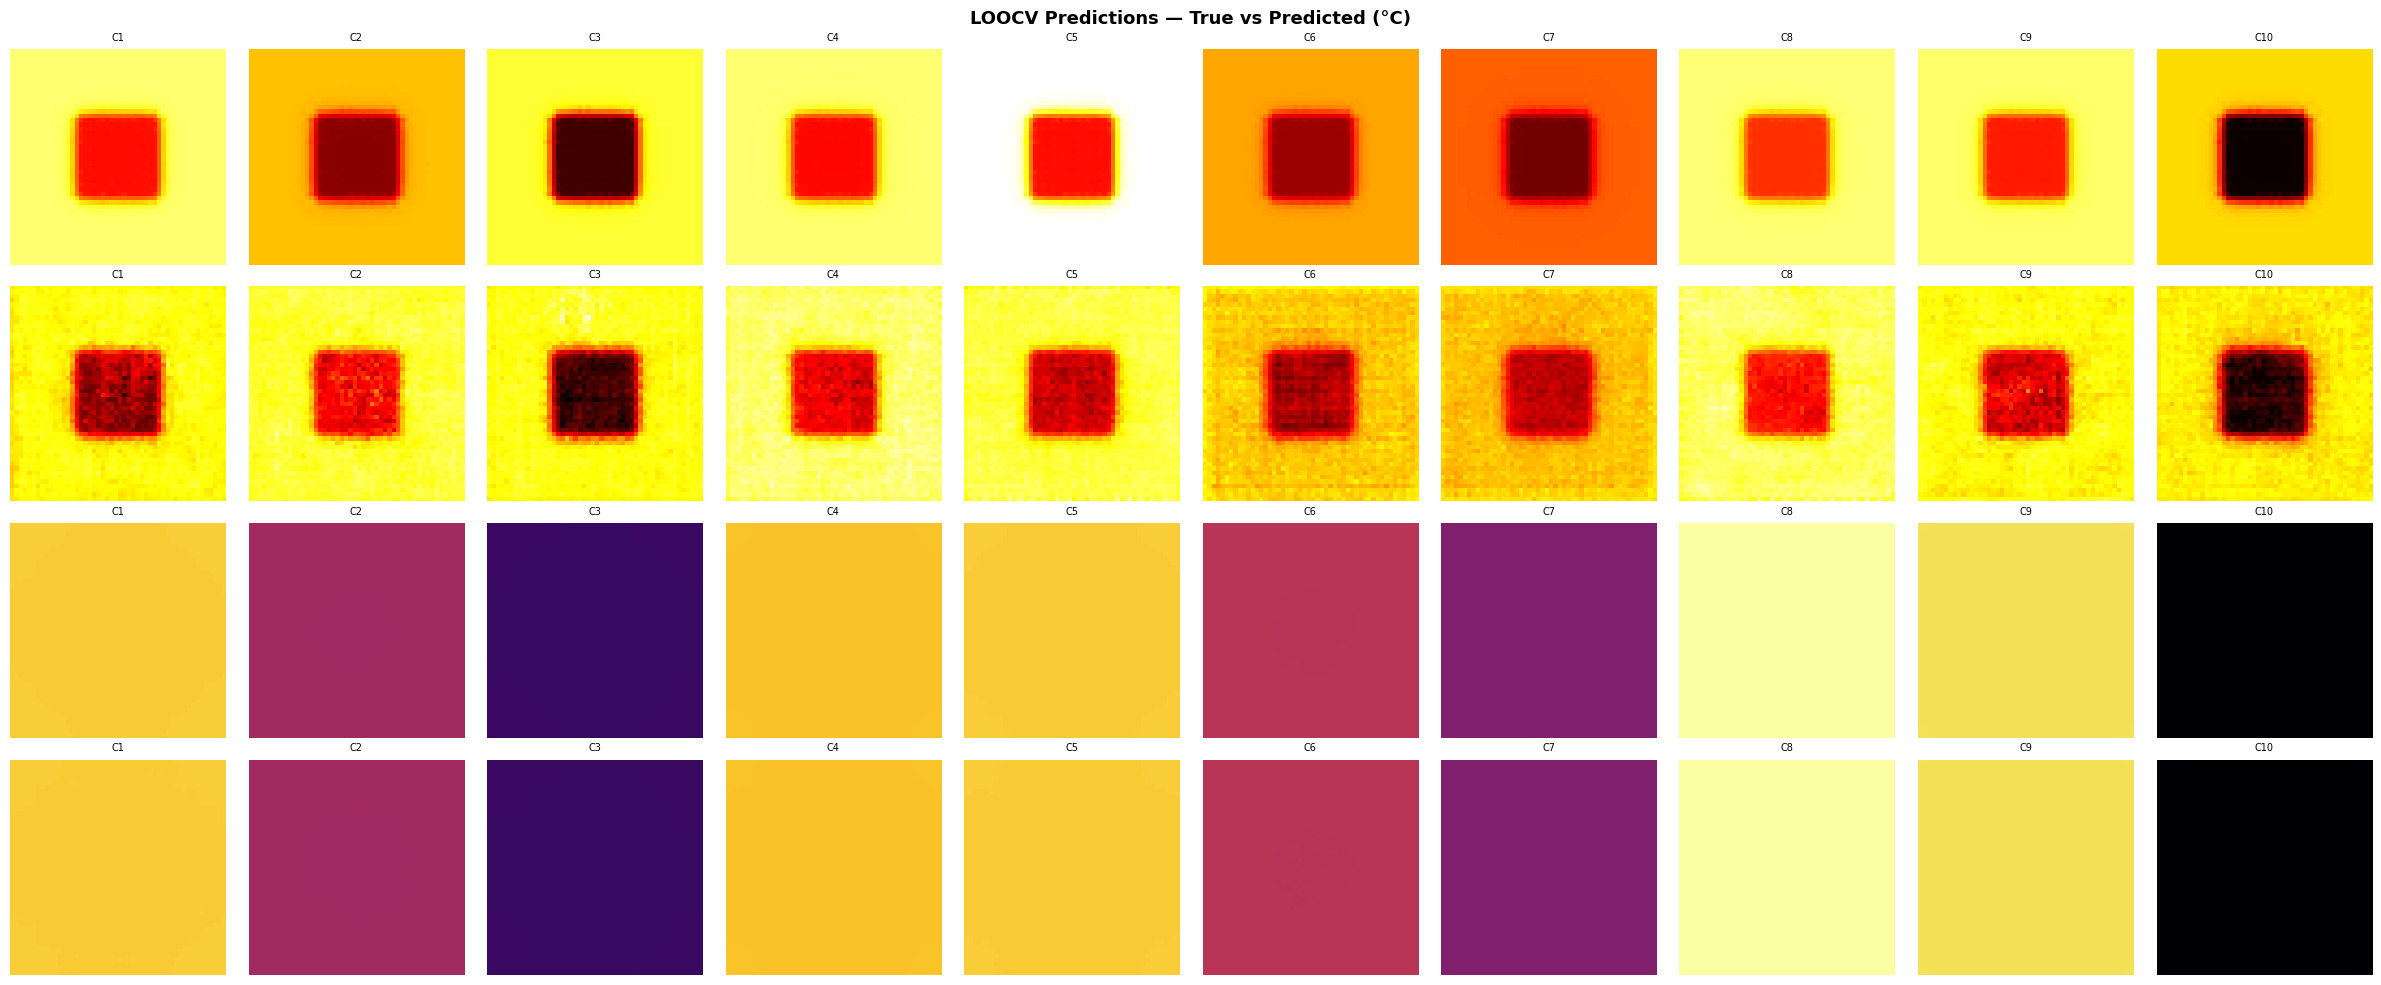

✅ Prediction comparison figure saved


In [43]:
# ── Prediction vs Ground Truth for all 10 cases ───────────────────────────────
fig, axes = plt.subplots(4, 10, figsize=(24, 10))

pcb_vmin = min(c['pcb'].min() for c in cases)
pcb_vmax = max(c['pcb'].max() for c in cases)
die_vmin = min(c['die'].min() for c in cases)
die_vmax = max(c['die'].max() for c in cases)

row_labels = ['PCB True', 'PCB Pred', 'DIE True', 'DIE Pred']

for i, r in enumerate(fold_results):
    out = r['outputs'][0]

    axes[0, i].imshow(out['pcb_true'], cmap='hot', vmin=pcb_vmin, vmax=pcb_vmax, origin='lower')
    axes[1, i].imshow(out['pcb_pred'], cmap='hot', vmin=pcb_vmin, vmax=pcb_vmax, origin='lower')
    axes[2, i].imshow(out['die_true'], cmap='inferno', vmin=die_vmin, vmax=die_vmax, origin='lower')
    axes[3, i].imshow(out['die_pred'], cmap='inferno', vmin=die_vmin, vmax=die_vmax, origin='lower')

    for row in range(4):
        axes[row, i].set_title(f'C{r["fold"]}', fontsize=7)
        axes[row, i].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=9, fontweight='bold')
    axes[row, 0].axis('off')

fig.suptitle('LOOCV Predictions — True vs Predicted (°C)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_predictions_all_cases.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Prediction comparison figure saved')

In [44]:
# ── MAE in real °C for each case ──────────────────────────────────────────────
print(f'{"Case":>6}  {"PCB MAE (°C)":>14}  {"DIE MAE (°C)":>14}  {"PCB RMSE":>10}  {"DIE RMSE":>10}')
print('-' * 60)

pcb_maes, die_maes = [], []
for r in fold_results:
    out = r['outputs'][0]
    pcb_mae = np.abs(out['pcb_pred'] - out['pcb_true']).mean()
    die_mae = np.abs(out['die_pred'] - out['die_true']).mean()
    pcb_rmse = np.sqrt(((out['pcb_pred'] - out['pcb_true'])**2).mean())
    die_rmse = np.sqrt(((out['die_pred'] - out['die_true'])**2).mean())
    pcb_maes.append(pcb_mae)
    die_maes.append(die_mae)
    print(f'  C{r["fold"]:>2d}   {pcb_mae:14.4f}  {die_mae:14.6f}  {pcb_rmse:10.4f}  {die_rmse:10.6f}')

print('-' * 60)
print(f'  Mean  {np.mean(pcb_maes):14.4f}  {np.mean(die_maes):14.6f}')
print(f'  Std   {np.std(pcb_maes):14.4f}  {np.std(die_maes):14.6f}')


  Case    PCB MAE (°C)    DIE MAE (°C)    PCB RMSE    DIE RMSE
------------------------------------------------------------
  C 1           3.0131        0.002841      3.1812    0.003500
  C 2           4.1125        0.003632      4.1946    0.004255
  C 3           0.9639        0.002143      1.1185    0.002811
  C 4           0.6477        0.002885      0.8529    0.003444
  C 5           4.7044        0.002682      4.8236    0.003305
  C 6           1.4185        0.002105      1.6111    0.002797
  C 7           4.0046        0.002523      4.0816    0.003166
  C 8           0.8355        0.002177      1.0433    0.002778
  C 9           2.6213        0.002589      2.7461    0.003324
  C10           0.9301        0.002618      1.1508    0.003239
------------------------------------------------------------
  Mean          2.3252        0.002619
  Std           1.4796        0.000430


🏋️ Training final model on ALL 10 cases...

  Epoch   50/300 | Loss: 0.2867
  Epoch  100/300 | Loss: 0.1703
  Epoch  150/300 | Loss: 0.1587
  Epoch  200/300 | Loss: 0.1677
  Epoch  250/300 | Loss: 0.1611
  Epoch  300/300 | Loss: 0.1608

✅ Final model trained


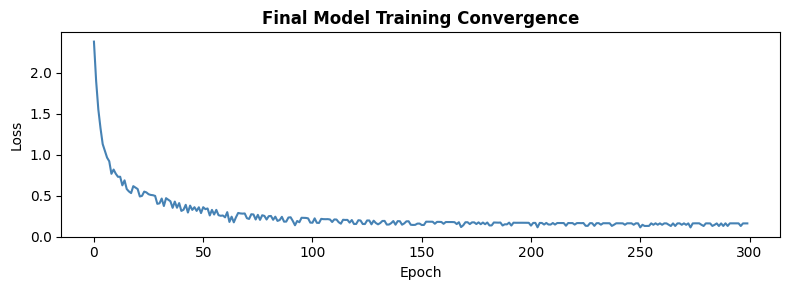

In [46]:
print('🏋️ Training final model on ALL 10 cases...\n')

FINAL_EPOCHS = 300

full_dataset = ThermalDataset(cases, X_scaled, list(range(len(cases))))  # ← added indices
full_loader  = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

final_model = ThermalDigitalTwin(in_features=len(FEATURE_COLS)).to(device)
optimizer   = torch.optim.AdamW(final_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINAL_EPOCHS)

final_hist = []

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    epoch_loss = 0.0
    for x, pcb, die, _ in full_loader:          # ← unpack 4 values
        x, pcb, die = x.to(device), pcb.to(device), die.to(device)
        pcb_pred, die_pred = final_model(x)
        loss, _ = physics_loss(pcb_pred, die_pred, pcb, die, LAMBDA_GRAD, LAMBDA_UNI)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    final_hist.append(epoch_loss / len(full_loader))

    if (epoch + 1) % 50 == 0:
        print(f'  Epoch {epoch+1:4d}/{FINAL_EPOCHS} | Loss: {final_hist[-1]:.4f}')

print('\n✅ Final model trained')

plt.figure(figsize=(8, 3))
plt.plot(final_hist, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Final Model Training Convergence', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_final_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize as pymoo_minimize

# ── SAC305 hard bounds ─────────────────────────────────────────────────────────
# Bounds for FEATURE_COLS in real (unscaled) space:
# peak_temp_C, tal_s, soak_temp_C, soak_time_s, ramp_rate_Cps,
# cooling_rate_Cps, t_total_s, T_amb_C, copper_area_fraction,
# paste_coverage_fraction, k_die_WmK, k_pcb_WmK

SAC305_BOUNDS_REAL = np.array([
    [235.0, 260.0],   # peak_temp_C
    [30.0,  60.0],    # tal_s
    [150.0, 180.0],   # soak_temp_C
    [60.0,  120.0],   # soak_time_s
    [1.0,   3.0],     # ramp_rate_Cps
    [1.5,   4.0],     # cooling_rate_Cps
    [200.0, 400.0],   # t_total_s
    [20.0,  30.0],    # T_amb_C
    [0.15,  0.35],    # copper_area_fraction
    [0.01,  0.03],    # paste_coverage_fraction
    [130.0, 148.0],   # k_die_WmK
    [0.3,   0.5],     # k_pcb_WmK
])

# Convert bounds to scaled space for optimization
lb_scaled = feature_scaler.transform(SAC305_BOUNDS_REAL[:, 0].reshape(1, -1))[0]
ub_scaled = feature_scaler.transform(SAC305_BOUNDS_REAL[:, 1].reshape(1, -1))[0]


class ReflowParetoOptimizer(Problem):
    def __init__(self):
        xl = np.minimum(lb_scaled, ub_scaled)
        xu = np.maximum(lb_scaled, ub_scaled)
        super().__init__(n_var=len(FEATURE_COLS), n_obj=2, n_constr=0, xl=xl, xu=xu)

    def _evaluate(self, X, out, *args, **kwargs):
        F = []
        final_model.eval()

        with torch.no_grad():
            for x_vec in X:
                x_t = torch.tensor(x_vec, dtype=torch.float32).unsqueeze(0).to(device)
                pcb_pred, die_pred = final_model(x_t)

                # Back to °C
                pcb_np = denormalize_pcb(pcb_pred.cpu().numpy()[0, 0])
                die_np = denormalize_die(die_pred.cpu().numpy()[0, 0])

                # ── Objective 1: PCB uniformity ──────────────────────────
                pcb_range = pcb_np.max() - pcb_np.min()
                pcb_grad  = np.mean(np.abs(np.gradient(pcb_np)))
                obj1 = pcb_range + 0.5 * pcb_grad

                # ── Objective 2: DIE uniformity ──────────────────────────
                die_range = die_np.max() - die_np.min()
                die_grad  = np.mean(np.abs(np.gradient(die_np)))
                obj2 = die_range + 0.5 * die_grad

                F.append([obj1, obj2])

        out['F'] = np.array(F)


print('✅ NSGA-II optimization problem defined')
print(f'   Variables  : {len(FEATURE_COLS)} (normalized reflow parameters)')
print( '   Objectives : 2 (PCB uniformity, DIE uniformity)')
print( '   Constraints: SAC305 hard bounds enforced via xl/xu')
#%%


✅ NSGA-II optimization problem defined
   Variables  : 12 (normalized reflow parameters)
   Objectives : 2 (PCB uniformity, DIE uniformity)
   Constraints: SAC305 hard bounds enforced via xl/xu


In [49]:
import torch.nn.functional as F
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.optimize import minimize as pymoo_minimize

# ── Global DIE denorm for optimizer (no case index available) ──────────────────
DIE_MEAN_GLOBAL = np.mean(DIE_MEANS)
DIE_STD_GLOBAL  = np.mean(DIE_STDS)

def denormalize_die_global(x):
    return x * DIE_STD_GLOBAL + DIE_MEAN_GLOBAL

# ── SAC305 hard bounds ─────────────────────────────────────────────────────────
SAC305_BOUNDS_REAL = np.array([
    [235.0, 260.0],   # peak_temp_C
    [30.0,  60.0],    # tal_s
    [150.0, 180.0],   # soak_temp_C
    [60.0,  120.0],   # soak_time_s
    [1.0,   3.0],     # ramp_rate_Cps
    [1.5,   4.0],     # cooling_rate_Cps
    [200.0, 400.0],   # t_total_s
    [20.0,  30.0],    # T_amb_C
    [0.15,  0.35],    # copper_area_fraction
    [0.01,  0.03],    # paste_coverage_fraction
    [130.0, 148.0],   # k_die_WmK
    [0.3,   0.5],     # k_pcb_WmK
])

lb_scaled = feature_scaler.transform(SAC305_BOUNDS_REAL[:, 0].reshape(1, -1))[0]
ub_scaled = feature_scaler.transform(SAC305_BOUNDS_REAL[:, 1].reshape(1, -1))[0]


class ReflowParetoOptimizer(Problem):
    def __init__(self):
        xl = np.minimum(lb_scaled, ub_scaled)
        xu = np.maximum(lb_scaled, ub_scaled)
        super().__init__(n_var=len(FEATURE_COLS), n_obj=2, n_constr=0, xl=xl, xu=xu)

    def _evaluate(self, X, out, *args, **kwargs):
        obj_vals = []
        final_model.eval()

        with torch.no_grad():
            for x_vec in X:
                x_t = torch.tensor(x_vec, dtype=torch.float32).unsqueeze(0).to(device)
                pcb_pred, die_pred = final_model(x_t)

                pcb_np = denormalize_pcb(pcb_pred.cpu().numpy()[0, 0])
                die_np = denormalize_die_global(die_pred.cpu().numpy()[0, 0])  # ← global

                # Objective 1: PCB uniformity
                pcb_range = pcb_np.max() - pcb_np.min()
                pcb_grad  = np.mean(np.abs(np.gradient(pcb_np)))
                obj1 = pcb_range + 0.5 * pcb_grad

                # Objective 2: DIE uniformity
                die_range = die_np.max() - die_np.min()
                die_grad  = np.mean(np.abs(np.gradient(die_np)))
                obj2 = die_range + 0.5 * die_grad

                obj_vals.append([obj1, obj2])

        out['F'] = np.array(obj_vals)


print('✅ NSGA-II optimization problem defined')
print(f'   Variables  : {len(FEATURE_COLS)} (normalized reflow parameters)')
print( '   Objectives : 2 (PCB uniformity, DIE uniformity)')
print( '   Constraints: SAC305 hard bounds enforced via xl/xu')
print(f'   DIE global denorm: mean={DIE_MEAN_GLOBAL:.4f}  std={DIE_STD_GLOBAL:.6f}')

# ── Run NSGA-II ────────────────────────────────────────────────────────────────
print('\n🚀 Running NSGA-II optimization...')

problem   = ReflowParetoOptimizer()
algorithm = NSGA2(
    pop_size=60,
    crossover=SBX(prob=0.9, eta=20),
    mutation=PM(prob=1.0/len(FEATURE_COLS), eta=20),
    eliminate_duplicates=True
)

result = pymoo_minimize(
    problem, algorithm,
    ('n_gen', 80),
    seed=42,
    verbose=True
)

print(f'\n✅ Optimization complete')
print(f'   Pareto front solutions: {len(result.F)}')
print(f'   PCB obj range: {result.F[:, 0].min():.4f} → {result.F[:, 0].max():.4f}')
print(f'   DIE obj range: {result.F[:, 1].min():.4f} → {result.F[:, 1].max():.4f}')

✅ NSGA-II optimization problem defined
   Variables  : 12 (normalized reflow parameters)
   Objectives : 2 (PCB uniformity, DIE uniformity)
   Constraints: SAC305 hard bounds enforced via xl/xu
   DIE global denorm: mean=228.0113  std=0.010146

🚀 Running NSGA-II optimization...
n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       60 |      1 |             - |             -
     2 |      120 |      2 |  2.7128815461 |         ideal
     3 |      180 |      4 |  0.7267096148 |         ideal
     4 |      240 |      4 |  0.0733202039 |         ideal
     5 |      300 |      3 |  0.0774020409 |         ideal
     6 |      360 |      5 |  0.2029668112 |         ideal
     7 |      420 |      8 |  0.0941302306 |         ideal
     8 |      480 |      7 |  0.1551667128 |         ideal
     9 |      540 |     11 |  0.0222105201 |         ideal
    10 |      600 |     16 |  0.0150502810 |         ideal
    11 |      660 |     17 |  0.0127103246 |             f
    12 |     

✅ Optimization complete
   Pareto front solutions: 60
   PCB obj range: 13.5639 → 14.4968
   DIE obj range: 0.0425 → 0.0451


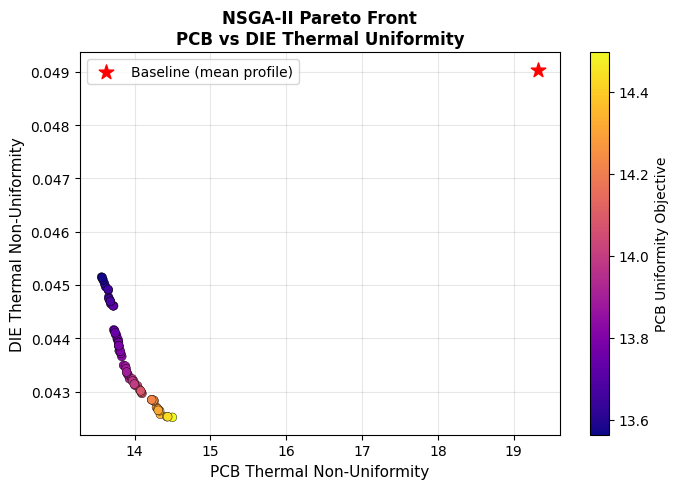

✅ Pareto front figure saved

=== 🏆 BEST OPTIMIZED REFLOW PROFILE ===

  peak_temp_C                   : 244.2136
  tal_s                         : 59.2607
  soak_temp_C                   : 171.1184
  soak_time_s                   : 110.8349
  ramp_rate_Cps                 : 2.0750
  cooling_rate_Cps              : 1.9614
  t_total_s                     : 315.3134
  T_amb_C                       : 24.9677
  copper_area_fraction          : 0.2633
  paste_coverage_fraction       : 0.0262
  k_die_WmK                     : 130.2342
  k_pcb_WmK                     : 0.4219

  PCB Uniformity Obj : 13.5639  (baseline: 19.3217)
  DIE Uniformity Obj : 0.0451  (baseline: 0.0490)

=== SAC305 Compliance Check ===
  ✅  Peak temp (235–260°C): 244.21
  ✅  TAL       (30–60s): 59.26
  ✅  Soak temp (150–180°C): 171.12
  ✅  Cooling   (1.5–4°C/s): 1.96


In [51]:
import torch.nn.functional as F

# ── Pareto Front Plot ──────────────────────────────────────────────────────────
pareto_F = result.F
X_pareto = result.X

print(f'✅ Optimization complete')
print(f'   Pareto front solutions: {len(pareto_F)}')
print(f'   PCB obj range: {pareto_F[:, 0].min():.4f} → {pareto_F[:, 0].max():.4f}')
print(f'   DIE obj range: {pareto_F[:, 1].min():.4f} → {pareto_F[:, 1].max():.4f}')

# Baseline (mean of training data)
baseline_x = X_scaled.mean(axis=0)
baseline_t  = torch.tensor(baseline_x, dtype=torch.float32).unsqueeze(0).to(device)
final_model.eval()
with torch.no_grad():
    bp, bd = final_model(baseline_t)
bp_np = denormalize_pcb(bp.cpu().numpy()[0, 0])
bd_np = denormalize_die_global(bd.cpu().numpy()[0, 0])  # ← fixed
baseline_F = [
    (bp_np.max()-bp_np.min()) + 0.5*np.mean(np.abs(np.gradient(bp_np))),
    (bd_np.max()-bd_np.min()) + 0.5*np.mean(np.abs(np.gradient(bd_np)))
]

# Colour by PCB obj
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(pareto_F[:, 0], pareto_F[:, 1], c=pareto_F[:, 0],
                cmap='plasma', s=40, zorder=3, edgecolors='k', linewidths=0.3)
ax.scatter(*baseline_F, color='red', s=120, marker='*', zorder=5, label='Baseline (mean profile)')
plt.colorbar(sc, ax=ax, label='PCB Uniformity Objective')
ax.set_xlabel('PCB Thermal Non-Uniformity', fontsize=11)
ax.set_ylabel('DIE Thermal Non-Uniformity', fontsize=11)
ax.set_title('NSGA-II Pareto Front\nPCB vs DIE Thermal Uniformity', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_pareto_front.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Pareto front figure saved')

# ── Best solution: minimum combined objective ──────────────────────────────────
combined = pareto_F[:, 0] + pareto_F[:, 1]
best_idx = np.argmin(combined)
best_x   = X_pareto[best_idx]
best_F   = pareto_F[best_idx]

best_real = feature_scaler.inverse_transform(best_x.reshape(1, -1))[0]

print('\n=== 🏆 BEST OPTIMIZED REFLOW PROFILE ===\n')
for name, val in zip(FEATURE_COLS, best_real):
    print(f'  {name:<30s}: {val:.4f}')
print()
print(f'  PCB Uniformity Obj : {best_F[0]:.4f}  (baseline: {baseline_F[0]:.4f})')
print(f'  DIE Uniformity Obj : {best_F[1]:.4f}  (baseline: {baseline_F[1]:.4f})')

# SAC305 compliance check
print('\n=== SAC305 Compliance Check ===')
checks = [
    ('Peak temp (235–260°C)', best_real[0], 235, 260),
    ('TAL       (30–60s)',    best_real[1],  30,  60),
    ('Soak temp (150–180°C)', best_real[2], 150, 180),
    ('Cooling   (1.5–4°C/s)', best_real[5], 1.5,  4.0),
]
for label, val, lo, hi in checks:
    status = '✅' if lo <= val <= hi else '❌'
    print(f'  {status}  {label}: {val:.2f}')

In [52]:
# ── Best solution: minimum combined objective ──────────────────────────────────
combined = pareto_F[:, 0] + pareto_F[:, 1]
best_idx = np.argmin(combined)
best_x   = X_pareto[best_idx]
best_F   = pareto_F[best_idx]

# Decode to real values
best_real = feature_scaler.inverse_transform(best_x.reshape(1, -1))[0]

print('=== 🏆 BEST OPTIMIZED REFLOW PROFILE ===')
print()
for name, val in zip(FEATURE_COLS, best_real):
    print(f'  {name:<30s}: {val:.4f}')
print()
print(f'  PCB Uniformity Obj : {best_F[0]:.4f}  (baseline: {baseline_F[0]:.4f})')
print(f'  DIE Uniformity Obj : {best_F[1]:.4f}  (baseline: {baseline_F[1]:.4f})')

# SAC305 compliance check
print('\n=== SAC305 Compliance Check ===')
checks = [
    ('Peak temp (235–260°C)', best_real[0], 235, 260),
    ('TAL       (30–60s)',    best_real[1],  30,  60),
    ('Soak temp (150–180°C)', best_real[2], 150, 180),
    ('Cooling   (1.5–4°C/s)', best_real[5], 1.5,  4.0),
]
for label, val, lo, hi in checks:
    status = '✅' if lo <= val <= hi else '❌'
    print(f'  {status}  {label}: {val:.2f}')

=== 🏆 BEST OPTIMIZED REFLOW PROFILE ===

  peak_temp_C                   : 244.2136
  tal_s                         : 59.2607
  soak_temp_C                   : 171.1184
  soak_time_s                   : 110.8349
  ramp_rate_Cps                 : 2.0750
  cooling_rate_Cps              : 1.9614
  t_total_s                     : 315.3134
  T_amb_C                       : 24.9677
  copper_area_fraction          : 0.2633
  paste_coverage_fraction       : 0.0262
  k_die_WmK                     : 130.2342
  k_pcb_WmK                     : 0.4219

  PCB Uniformity Obj : 13.5639  (baseline: 19.3217)
  DIE Uniformity Obj : 0.0451  (baseline: 0.0490)

=== SAC305 Compliance Check ===
  ✅  Peak temp (235–260°C): 244.21
  ✅  TAL       (30–60s): 59.26
  ✅  Soak temp (150–180°C): 171.12
  ✅  Cooling   (1.5–4°C/s): 1.96


/tmp/ipython-input-633/2588901693.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


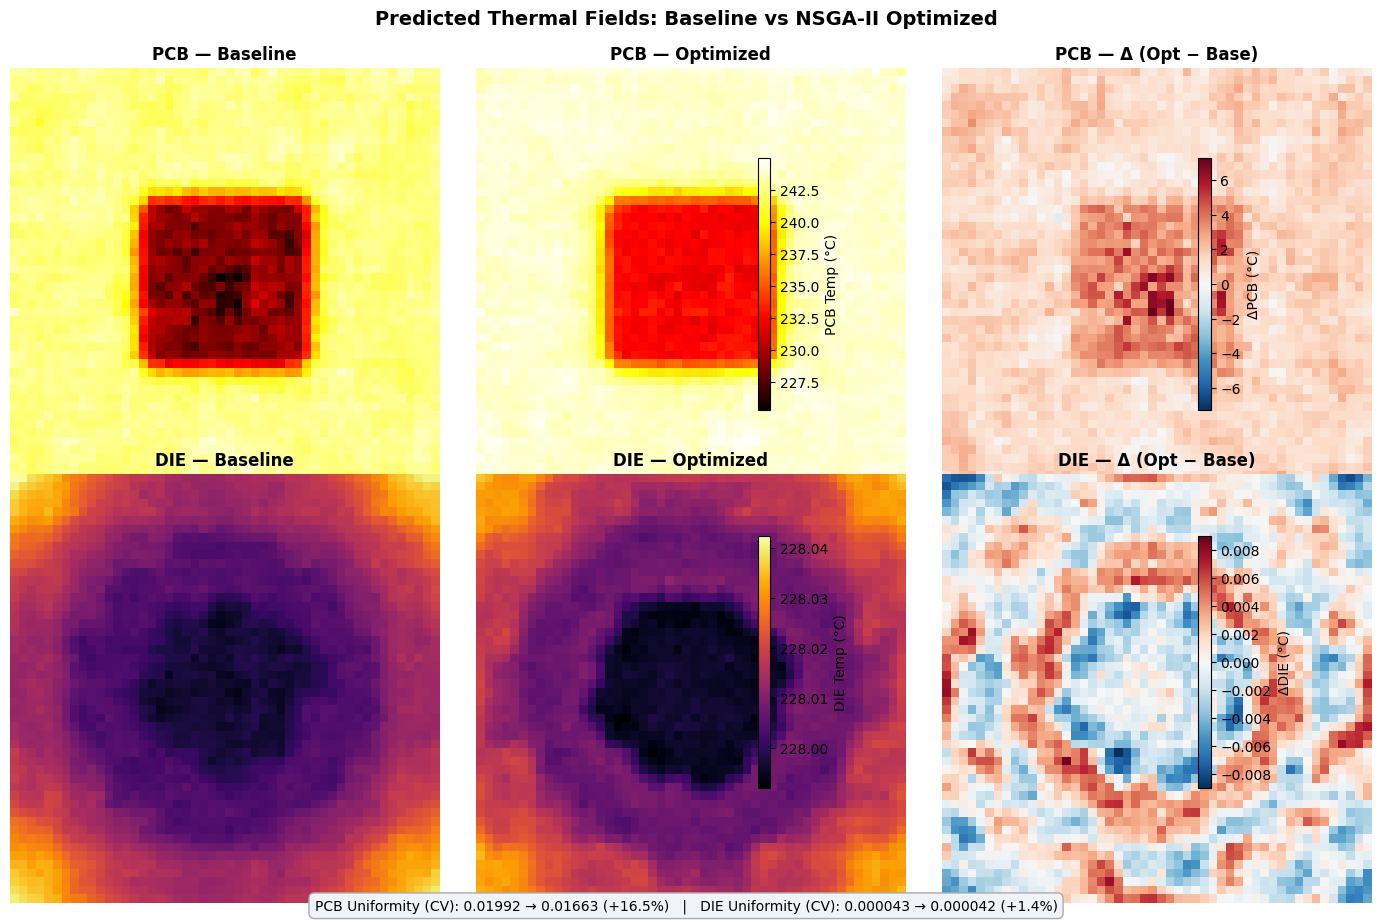

✅ Comparison figure saved


In [54]:
# ── Baseline vs Optimized Thermal Maps ────────────────────────────────────────
best_t = torch.tensor(best_x, dtype=torch.float32).unsqueeze(0).to(device)
final_model.eval()
with torch.no_grad():
    pcb_opt, die_opt   = final_model(best_t)
    pcb_base, die_base = final_model(baseline_t)

pcb_opt_np  = denormalize_pcb(pcb_opt.cpu().numpy()[0, 0])
die_opt_np  = denormalize_die_global(die_opt.cpu().numpy()[0, 0])   # ← fixed
pcb_base_np = denormalize_pcb(pcb_base.cpu().numpy()[0, 0])
die_base_np = denormalize_die_global(die_base.cpu().numpy()[0, 0])  # ← fixed

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

pcb_v = dict(vmin=min(pcb_base_np.min(), pcb_opt_np.min()),
             vmax=max(pcb_base_np.max(), pcb_opt_np.max()))
die_v = dict(vmin=min(die_base_np.min(), die_opt_np.min()),
             vmax=max(die_base_np.max(), die_opt_np.max()))

im0 = axes[0,0].imshow(pcb_base_np, cmap='hot',     origin='lower', **pcb_v)
axes[0,0].set_title('PCB — Baseline', fontweight='bold')
im1 = axes[0,1].imshow(pcb_opt_np,  cmap='hot',     origin='lower', **pcb_v)
axes[0,1].set_title('PCB — Optimized', fontweight='bold')
diff_pcb = pcb_opt_np - pcb_base_np
lim = max(abs(diff_pcb.min()), abs(diff_pcb.max()))
im2 = axes[0,2].imshow(diff_pcb, cmap='RdBu_r', origin='lower', vmin=-lim, vmax=lim)
axes[0,2].set_title('PCB — Δ (Opt − Base)', fontweight='bold')

im3 = axes[1,0].imshow(die_base_np, cmap='inferno', origin='lower', **die_v)
axes[1,0].set_title('DIE — Baseline', fontweight='bold')
im4 = axes[1,1].imshow(die_opt_np,  cmap='inferno', origin='lower', **die_v)
axes[1,1].set_title('DIE — Optimized', fontweight='bold')
diff_die = die_opt_np - die_base_np
lim2 = max(abs(diff_die.min()), abs(diff_die.max()))
im5 = axes[1,2].imshow(diff_die, cmap='RdBu_r', origin='lower', vmin=-lim2, vmax=lim2)
axes[1,2].set_title('DIE — Δ (Opt − Base)', fontweight='bold')

for ax, im, label in [
    (axes[0,:2], im1, 'PCB Temp (°C)'),
    (axes[1,:2], im4, 'DIE Temp (°C)'),
    (axes[0,2:], im2, 'ΔPCB (°C)'),
    (axes[1,2:], im5, 'ΔDIE (°C)'),
]:
    fig.colorbar(im, ax=ax, shrink=0.8, label=label)

for ax in axes.flat:
    ax.axis('off')

pcb_cv_base = pcb_base_np.std() / pcb_base_np.mean()
pcb_cv_opt  = pcb_opt_np.std()  / pcb_opt_np.mean()
die_cv_base = die_base_np.std() / die_base_np.mean()
die_cv_opt  = die_opt_np.std()  / die_opt_np.mean()

fig.text(0.5, 0.01,
    f'PCB Uniformity (CV): {pcb_cv_base:.5f} → {pcb_cv_opt:.5f} '
    f'({(pcb_cv_base-pcb_cv_opt)/pcb_cv_base*100:+.1f}%)   |   '
    f'DIE Uniformity (CV): {die_cv_base:.6f} → {die_cv_opt:.6f} '
    f'({(die_cv_base-die_cv_opt)/die_cv_base*100:+.1f}%)',
    ha='center', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.4', fc='#f0f4f8', ec='#aaa'))

fig.suptitle('Predicted Thermal Fields: Baseline vs NSGA-II Optimized', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_baseline_vs_optimized.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Comparison figure saved')

In [55]:
# ── Save numerical results JSON ────────────────────────────────────────────────
results = {
    'loocv': {
        'mean_loss':    float(np.mean(val_losses)),
        'std_loss':     float(np.std(val_losses)),
        'per_fold':     [{'fold': int(r['fold']), 'val_loss': float(r['val_loss'])} for r in fold_results],
        'pcb_mae_mean': float(np.mean(pcb_maes)),
        'die_mae_mean': float(np.mean(die_maes)),
    },
    'optimization': {
        'pareto_solutions': int(len(pareto_F)),
        'best_profile':     {k: float(v) for k, v in zip(FEATURE_COLS, best_real)},
        'best_pcb_obj':     float(best_F[0]),
        'best_die_obj':     float(best_F[1]),
        'baseline_pcb_obj': float(baseline_F[0]),
        'baseline_die_obj': float(baseline_F[1]),
    },
    'model': {
        'architecture': 'ThermalDigitalTwin (shared encoder, separate PCB+DIE decoders)',
        'in_features':  int(len(FEATURE_COLS)),
        'n_params':     int(sum(p.numel() for p in final_model.parameters())),
        'loss':         'MSE(PCB) + MSE(DIE) + λ·Gradient(PCB) + λ·Uniformity(DIE)',
    }
}

results_path = OUTPUT_DIR / 'results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f'✅ Results saved to: {results_path}')

# ── Print summary ──────────────────────────────────────────────────────────────
print(f"""
╔══════════════════════════════════════════════════════╗
║        PCB Reflow Thermal Digital Twin — Summary    ║
╠══════════════════════════════════════════════════════╣
║  LOOCV Mean Loss    : {np.mean(val_losses):.4f}                       ║
║  PCB MAE            : {np.mean(pcb_maes):.4f} °C                    ║
║  DIE MAE            : {np.mean(die_maes):.6f} °C                  ║
║  Pareto Solutions   : {int(len(pareto_F))}                            ║
║  PCB obj improvement: {(baseline_F[0]-best_F[0])/baseline_F[0]*100:+.1f}%                     ║
║  DIE obj improvement: {(baseline_F[1]-best_F[1])/baseline_F[1]*100:+.1f}%                     ║
╚══════════════════════════════════════════════════════╝
""")

✅ Results saved to: /content/drive/My Drive/Data/AI MODEL TRAINING DATA/AI MODEL TRAINING DATA/outputs/results.json

╔══════════════════════════════════════════════════════╗
║        PCB Reflow Thermal Digital Twin — Summary    ║
╠══════════════════════════════════════════════════════╣
║  LOOCV Mean Loss    : 0.4408                       ║
║  PCB MAE            : 2.3252 °C                    ║
║  DIE MAE            : 0.002619 °C                  ║
║  Pareto Solutions   : 60                            ║
║  PCB obj improvement: +29.8%                     ║
║  DIE obj improvement: +7.9%                     ║
╚══════════════════════════════════════════════════════╝



In [56]:
# ── Optional: download model ───────────────────────────────────────────────────
from google.colab import files
files.download(str(save_path))
files.download(str(results_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

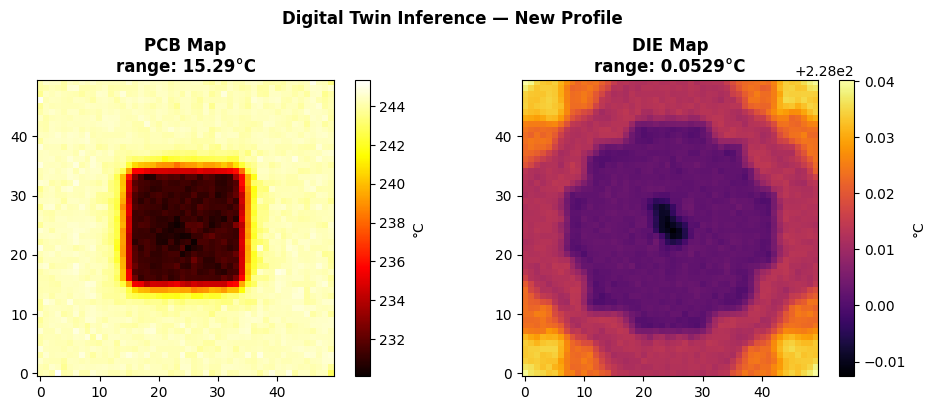

PCB: 230.07 → 245.36 °C
DIE: 227.9874 → 228.0402 °C


In [58]:
def predict_thermal_fields(profile_dict, model=final_model):
    """
    Predict PCB and DIE thermal maps for a given reflow profile.

    Args:
        profile_dict: dict with keys matching FEATURE_COLS, values in real units

    Returns:
        pcb_map (50×50 °C), die_map (50×50 °C)
    """
    x_raw = np.array([[profile_dict[k] for k in FEATURE_COLS]], dtype=np.float32)
    x_scaled = feature_scaler.transform(x_raw)
    x_t = torch.tensor(x_scaled, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        pcb_pred, die_pred = model(x_t)

    pcb_map = denormalize_pcb(pcb_pred.cpu().numpy()[0, 0])
    die_map = denormalize_die_global(die_pred.cpu().numpy()[0, 0])

    return pcb_map, die_map


# ── Example inference ──────────────────────────────────────────────────────────
new_profile = {
    'peak_temp_C':            245.0,
    'tal_s':                   45.0,
    'soak_temp_C':            165.0,
    'soak_time_s':             90.0,
    'ramp_rate_Cps':            1.5,
    'cooling_rate_Cps':         3.0,
    't_total_s':              291.0,
    'T_amb_C':                 25.0,
    'copper_area_fraction':     0.2,
    'paste_coverage_fraction':  0.01,
    'k_die_WmK':              130.0,
    'k_pcb_WmK':                0.3,
}

pcb_map, die_map = predict_thermal_fields(new_profile)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
im1 = ax1.imshow(pcb_map, cmap='hot', origin='lower')
ax1.set_title(f'PCB Map\nrange: {pcb_map.max()-pcb_map.min():.2f}°C', fontweight='bold')
plt.colorbar(im1, ax=ax1, label='°C')

im2 = ax2.imshow(die_map, cmap='inferno', origin='lower')
ax2.set_title(f'DIE Map\nrange: {die_map.max()-die_map.min():.4f}°C', fontweight='bold')
plt.colorbar(im2, ax=ax2, label='°C')

fig.suptitle('Digital Twin Inference — New Profile', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PCB: {pcb_map.min():.2f} → {pcb_map.max():.2f} °C')
print(f'DIE: {die_map.min():.4f} → {die_map.max():.4f} °C')